In [1]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset

#df = pd.read_csv('/content/sample_data/healthcare_dataset.csv')

df = pd.read_csv("data/healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 1. Dataset Overview

In [3]:
#Shape
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 55500
Columns : 15


In [4]:
#Column Names
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [5]:
#Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
#Statistical Summary
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [7]:
#Statistical Summary (Including Categorical Columns)
df.describe(include='object')

,Name,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500,55500
unique,49992,2,8,6,1827,40341,39876,5,3,1856,5,3
top,DAvId muNoZ,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,Elective,2020-03-15,Lipitor,Abnormal
freq,3,27774,6969,9308,50,27,44,11249,18655,53,11140,18627


## 2. Data Quality Checks

In [8]:
#Missing Values
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [9]:
#Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 534


In [10]:
#Dropping Duplicate Records
df = df.drop_duplicates()

In [11]:
#Check Unique Values
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Name: 49992
Age: 77
Gender: 2
Blood Type: 8
Medical Condition: 6
Date of Admission: 1827
Doctor: 40341
Hospital: 39876
Insurance Provider: 5
Billing Amount: 50000
Room Number: 400
Admission Type: 3
Discharge Date: 1856
Medication: 5
Test Results: 3


## 3. Data Cleaning

In [12]:
# Convert date columns to datetime format

df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [13]:
# Check for Invalid Ages
print("Minimum Age :", df['Age'].min())
print("Maximum Age :", df['Age'].max())

Minimum Age : 13
Maximum Age : 89


In [14]:
# Number of negative billing records
print("Negative Billing Records:", (df['Billing Amount'] < 0).sum())

# View some of them
df[df['Billing Amount'] < 0].head(10)

Negative Billing Records: 106


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
1421,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal
2696,Scott VaZqUEz,74,Male,B+,Diabetes,2023-04-12,Edward Yates,James Ltd,Medicare,-135.986000,445,Elective,2023-05-03,Ibuprofen,Abnormal
2855,CaROl aNDErSoN,39,Female,B-,Hypertension,2020-04-03,Dr. Patrick Hines,"Carter Carter, and Patterson",Blue Cross,-370.983674,203,Elective,2020-04-10,Ibuprofen,Abnormal
3772,mr. ChRIStOPhER aLvARaDO,77,Male,AB+,Obesity,2022-06-03,Mr. Dean Guzman DDS,Johnson Inc,Blue Cross,-1310.272895,257,Elective,2022-06-13,Paracetamol,Inconclusive
5445,ALExAndrA KHaN,32,Male,AB+,Arthritis,2022-07-14,Michael Vaughn,"Bowen Lopez, and Terry",Aetna,-692.408820,372,Elective,2022-07-19,Lipitor,Abnormal
5708,JosEPh cOx,23,Male,AB-,Diabetes,2019-10-13,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,2019-10-25,Lipitor,Inconclusive


In [15]:
# Remove records with negative billing amounts
df = df[df['Billing Amount'] >= 0]

In [16]:
# Number of negative billing records
print("Negative Billing Records:", (df['Billing Amount'] < 0).sum())

Negative Billing Records: 0


In [17]:
# Length of Stay
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Admission Month
df['Admission Month'] = df['Date of Admission'].dt.month_name()

# Admission Year
df['Admission Year'] = df['Date of Admission'].dt.year

# Age Group
bins = [0, 18, 35, 50, 65, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '66+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

In [18]:
df[['Age', 'Age Group', 'Length of Stay', 'Admission Month', 'Admission Year']].head()

,Age,Age Group,Length of Stay,Admission Month,Admission Year
0,30,19-35,2,January,2024
1,62,51-65,6,August,2019
2,76,66+,15,September,2022
3,28,19-35,30,November,2020
4,43,36-50,20,September,2022


## 4. Exploratory Data Analysis

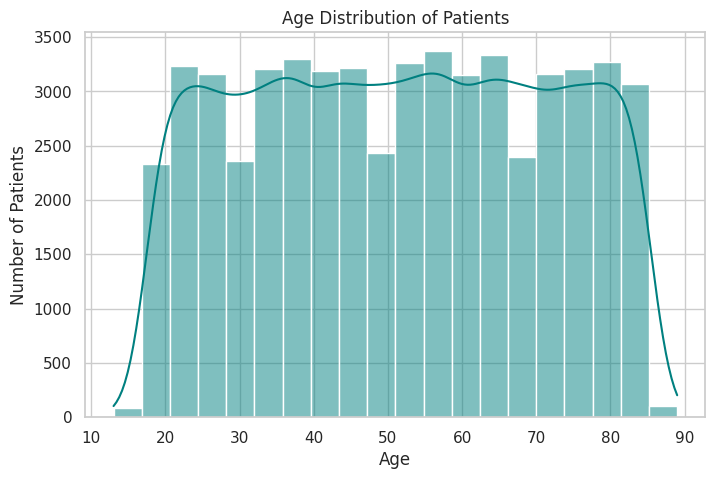

In [31]:
# Chart 1: Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True, color='teal')

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

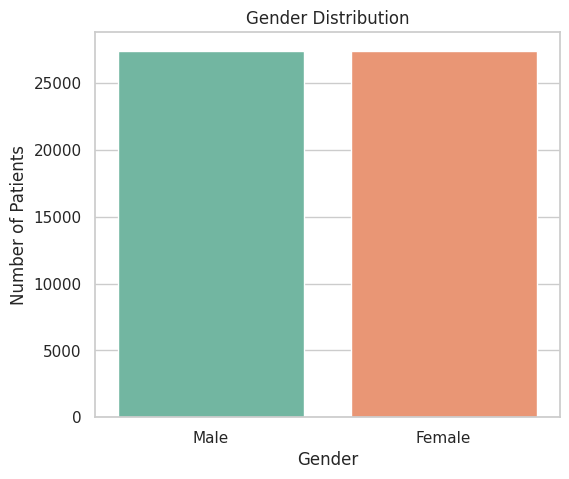

In [20]:
# Chart 2: Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(x='Gender', data=df, palette='Set2')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.show()

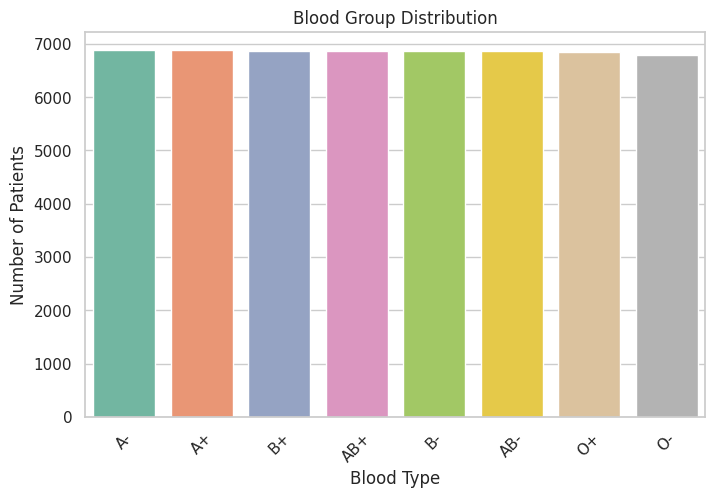

In [21]:
# Chart 3: Blood Group Distribution
plt.figure(figsize=(8,5))

sns.countplot(x='Blood Type', data=df, palette='Set2', order=df['Blood Type'].value_counts().index)

plt.title('Blood Group Distribution')
plt.xlabel('Blood Type')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45)

plt.show()

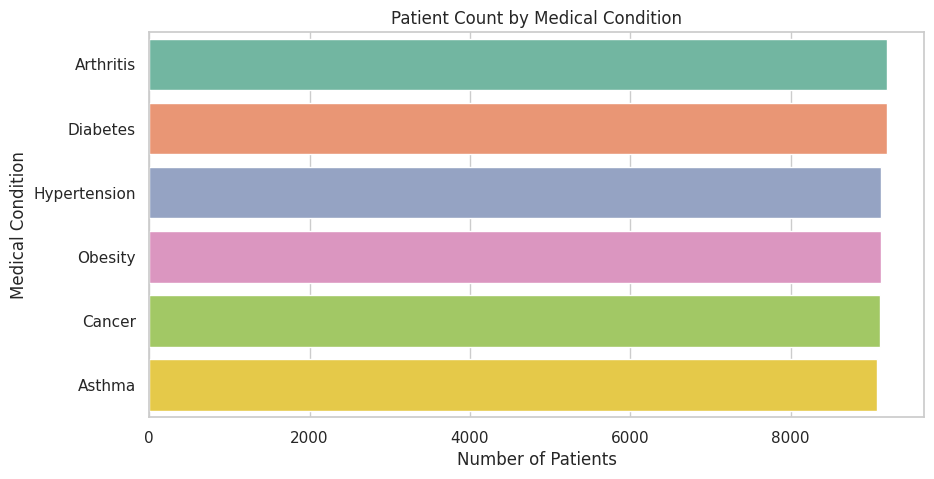

In [22]:
# Chart 4: Medical Condition Distribution
plt.figure(figsize=(10,5))

sns.countplot(y='Medical Condition', data=df, palette='Set2', order=df['Medical Condition'].value_counts().index)

plt.title('Patient Count by Medical Condition')
plt.xlabel('Number of Patients')
plt.ylabel('Medical Condition')

plt.show()

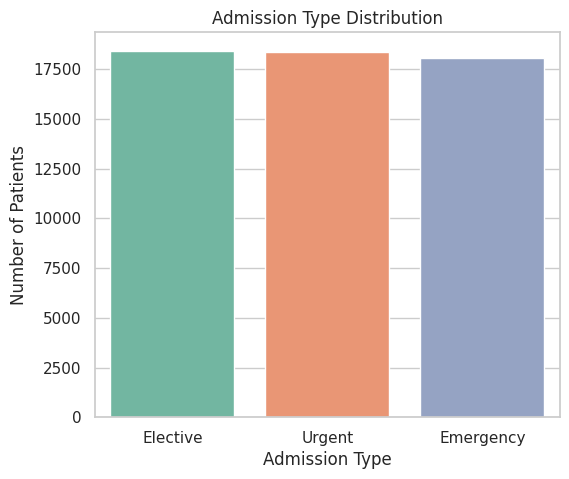

In [23]:
# Chart 5: Admission Type Distribution
plt.figure(figsize=(6,5))

sns.countplot(x='Admission Type', data=df, palette='Set2', order=df['Admission Type'].value_counts().index)

plt.title('Admission Type Distribution')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')

plt.show()

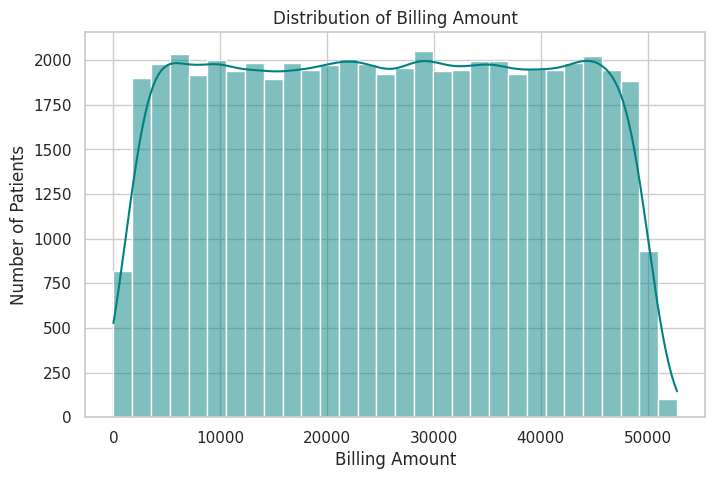

In [24]:
# Chart 6: Billing Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Billing Amount'], bins=30, kde=True, color='teal')

plt.title('Distribution of Billing Amount')
plt.xlabel('Billing Amount')
plt.ylabel('Number of Patients')

plt.show()

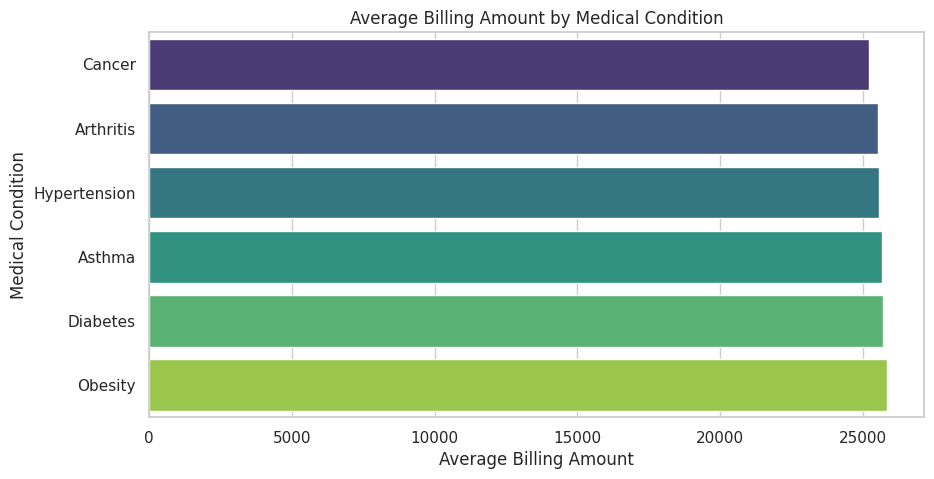

In [25]:
# Chart 7: Average Billing Amount by Medical Condition
plt.figure(figsize=(10,5))

avg_bill = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values()

sns.barplot(x=avg_bill.values, y=avg_bill.index, palette='viridis')

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Average Billing Amount')
plt.ylabel('Medical Condition')

plt.show()

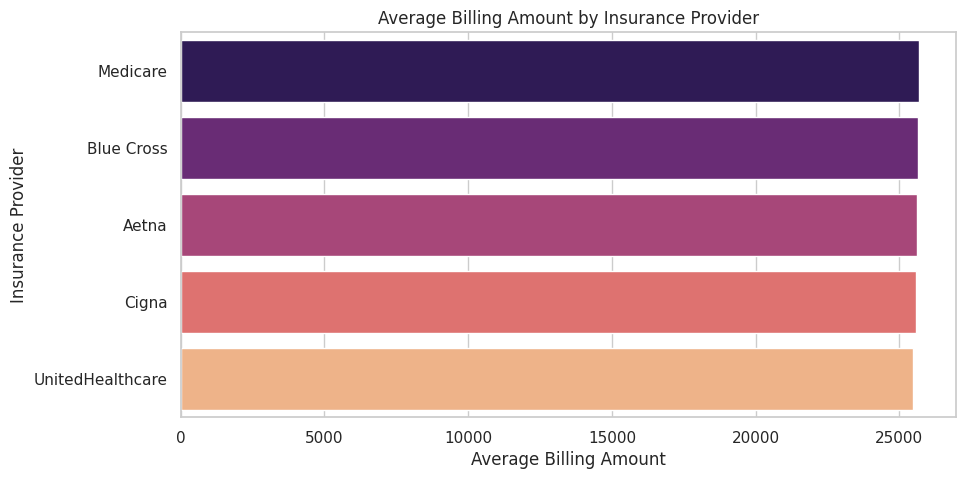

In [26]:
# Chart 8: Average Billing Amount by Insurance Provider
plt.figure(figsize=(10,5))

avg_insurance = (df.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=False))

sns.barplot(x=avg_insurance.values, y=avg_insurance.index, palette='magma')

plt.title('Average Billing Amount by Insurance Provider')
plt.xlabel('Average Billing Amount')
plt.ylabel('Insurance Provider')

plt.show()

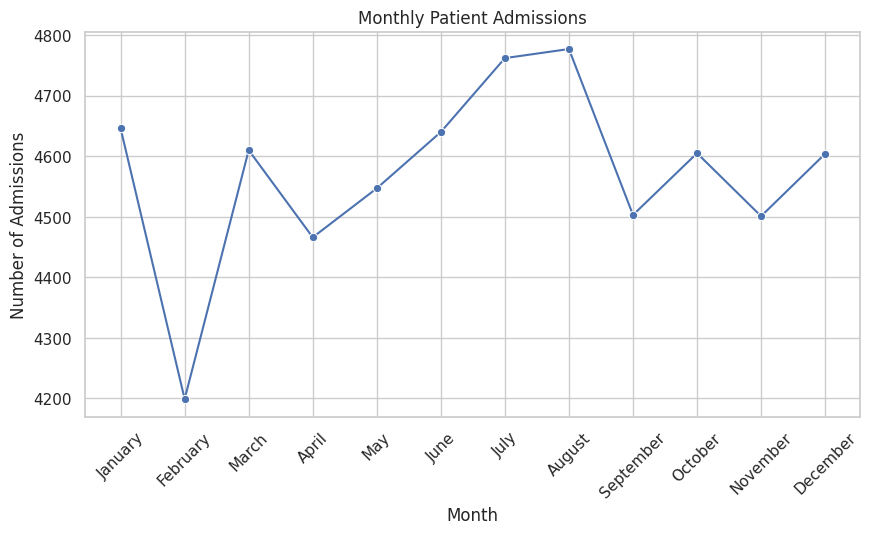

In [27]:
# Chart 9: Monthly Patient Admissions
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

monthly = (df['Admission Month'].value_counts().reindex(month_order))

plt.figure(figsize=(10,5))

sns.lineplot(x=monthly.index, y=monthly.values, marker='o')

plt.xticks(rotation=45)

plt.title('Monthly Patient Admissions')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')

plt.show()

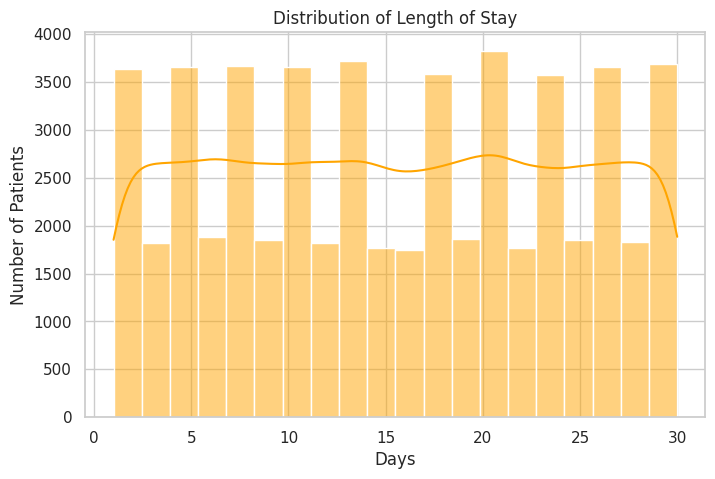

In [28]:
# Chart 10: Length of Stay Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Length of Stay'], bins=20, kde=True, color='orange')

plt.title('Distribution of Length of Stay')
plt.xlabel('Days')
plt.ylabel('Number of Patients')

plt.show()

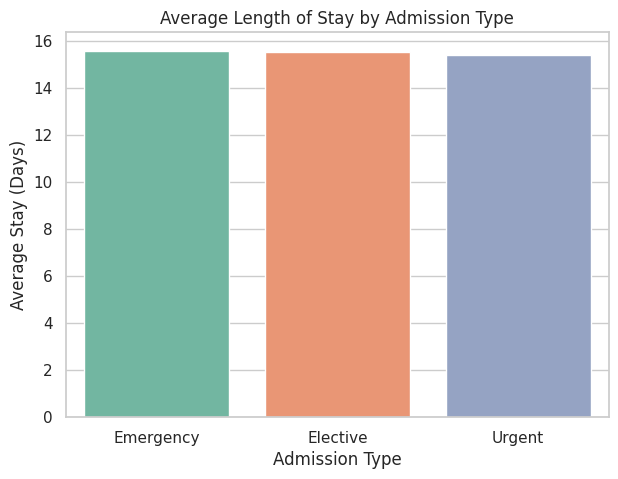

In [29]:
# Chart 11: Average Length of Stay by Admission Type
plt.figure(figsize=(7,5))

stay = (df.groupby('Admission Type')['Length of Stay'].mean().sort_values(ascending=False))

sns.barplot(x=stay.index, y=stay.values, palette='Set2')

plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Average Stay (Days)')

plt.show()

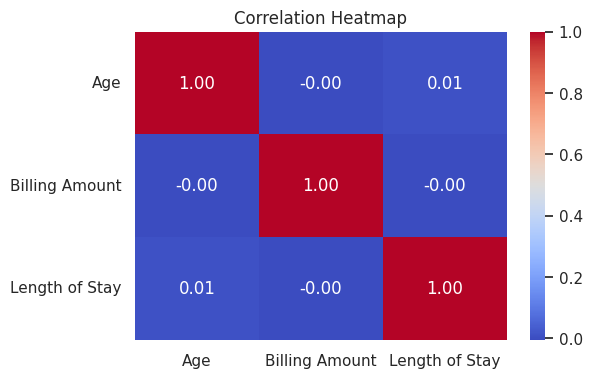

In [30]:
# Chart 12: Correlation Heatmap
plt.figure(figsize=(6,4))

corr = df[['Age', 'Billing Amount', 'Length of Stay']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

# Key Business Insights

*   The dataset contains a balanced distribution of patients across gender, blood groups, and admission types.
*   Cancer treatments have the highest average billing amounts, while obesity-related treatments have the lowest.
*   Medicare patients have the highest average healthcare bills among the insurance providers.
*   Patient admissions remain fairly consistent throughout the year, with a slight increase in August.
*   Hospital stay durations are generally spread between 1 and 30 days without major clustering.
*   Emergency admissions have a marginally longer average stay than elective and urgent admissions.
*   Billing amounts vary widely among patients, indicating diverse treatment costs.
*   No strong relationship exists between patient age, billing amount, and hospital stay duration in this dataset.


# Recommendations


*   Monitor high-cost medical conditions, particularly cancer, to identify opportunities for cost optimization.
*   Ensure adequate staffing and resource planning during months with relatively higher admissions.
*   Review billing practices periodically to maintain consistency across insurance providers.
*   Continue monitoring hospital stay durations to identify cases that may benefit from improved discharge planning.
*   Perform deeper analysis with additional clinical variables, as age alone does not explain billing or length of stay in this dataset.